# Week 6 workshop · Kuramoto synchronisation


**Canonical model:** Kuramoto coupled oscillators.

**Modelling practice:** Individual heterogeneity shapes collective thresholds.

**Why it matters:** An apparent collective threshold can depend on who is in the population and how large that population is.

**How it appears here:** Frequency distributions and finite oscillator populations are varied while coherence and the apparent onset of synchronisation are measured.

By the end, you should be able to explain how the distribution of individual frequencies and finite population size alter the observed onset of collective synchronisation.

# From the lecture to the workshop

The lecture moves from a pair of phase oscillators to the all-to-all Kuramoto model. The workshop follows the same route numerically, keeping phase trajectories and the collective order parameter visible together.

Earlier workshops supplied several extensions labelled A–D. From this week, some of that scaffolding is removed. As you begin planning your project, you should increasingly decide what to change, what to keep fixed and what evidence would answer your question. This workshop still provides several possible directions, but it does not turn each one into a complete investigation for you.

**Canonical model used here:** Kuramoto coupled oscillators.

This notebook needs Python 3.10 or later, NumPy, Matplotlib, and IPython. It is self-contained and does not require the lecture repository or separate files. Run the cells in order from a fresh kernel.


In [12]:
from dataclasses import dataclass
import json

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import HTML, display

SEED = 3024
INK = "#1B2A4C"
BLUE = "#5879AA"
YELLOW = "#EDCC55"

print(f"NumPy {np.__version__} · seed {SEED}")


NumPy 2.4.2 · seed 3024


# Begin with uncoupled oscillators

For $\dot\theta_i=\omega_i$, forward Euler gives

$$
\theta_i^{n+1}=\theta_i^n+\Delta t\,\omega_i \pmod{2\pi}.
$$

Because the derivative is constant, this numerical update agrees with the exact solution at the sampled times.


In [13]:
def wrap_phase(phases: np.ndarray) -> np.ndarray:
    """Wrap phases into [-pi, pi)."""
    return (np.asarray(phases, dtype=float) + np.pi) % (2 * np.pi) - np.pi


def uncoupled_step(phases: np.ndarray, frequencies: np.ndarray, dt: float) -> np.ndarray:
    phases = np.asarray(phases, dtype=float)
    frequencies = np.asarray(frequencies, dtype=float)
    if phases.shape != frequencies.shape:
        raise ValueError("phases and frequencies must have the same shape")
    if dt <= 0:
        raise ValueError("dt must be positive")
    return wrap_phase(phases + dt * frequencies)


phases = np.array([0.0, 0.0])
frequencies = np.array([1.0, 1.3])
assert np.allclose(uncoupled_step(phases, frequencies, 0.1), [0.1, 0.13])
print("Uncoupled update test passed.")


Uncoupled update test passed.


# Specify the Kuramoto model

| Ingredient | Workshop choice |
|---|---|
| Oscillator state | phase $\theta_i$ |
| Internal dynamics | fixed natural frequency $\omega_i$ |
| Network | equally weighted complete graph |
| Interaction | $\sin(\theta_j-\theta_i)$ |
| Control parameter | coupling strength $K$ |
| Numerical update | synchronous forward Euler |
| Observable | coherence $r$ |

> **Modelling choice:** The frequency distribution, coupling function, network, timestep, and initial phases are separate choices.


In [14]:
@dataclass(frozen=True)
class KuramotoParameters:
    n_oscillators: int = 80
    coupling: float = 1.5
    dt: float = 0.05
    frequency_sd: float = 1.0

    def __post_init__(self):
        if self.n_oscillators < 1:
            raise ValueError("n_oscillators must be positive")
        if self.dt <= 0 or self.frequency_sd < 0 or self.coupling < 0:
            raise ValueError("dt must be positive; frequency_sd and coupling cannot be negative")


def initialise_kuramoto(params: KuramotoParameters, rng: np.random.Generator):
    phases = rng.uniform(-np.pi, np.pi, params.n_oscillators)
    frequencies = rng.normal(0.0, params.frequency_sd, params.n_oscillators)
    frequencies -= frequencies.mean()
    return phases, frequencies


# Inspect the coupling term

For all-to-all coupling,

$$
C_i=\frac{1}{N}\sum_j\sin(\theta_j-\theta_i).
$$

> **Discuss:** What should $C_i$ be when all phases are identical? What sign should it have for an oscillator lagging just behind a coherent group?

> **Down the ladder:** test the local response before embedding it in a population trajectory.


In [15]:
def kuramoto_coupling(phases: np.ndarray) -> np.ndarray:
    """Return the all-to-all sinusoidal coupling experienced by each oscillator."""
    phases = np.asarray(phases, dtype=float)
    if phases.ndim != 1:
        raise ValueError("phases must be one-dimensional")
    order_parameter = np.mean(np.exp(1j * phases))
    return np.imag(order_parameter * np.exp(-1j * phases))


assert np.allclose(kuramoto_coupling(np.zeros(5)), 0.0)
opposite_pair = np.array([0.0, np.pi])
assert np.allclose(kuramoto_coupling(opposite_pair), 0.0, atol=1e-12)
print("Coupling tests passed.")


Coupling tests passed.


# Apply one synchronous update

$$
\theta_i^{n+1}
=\theta_i^n+\Delta t\left[
\omega_i+K C_i(\boldsymbol\theta^n)
\right]\pmod{2\pi}.
$$

All coupling terms must be calculated from the same previous phase vector.


In [16]:
def kuramoto_step(
    phases: np.ndarray,
    frequencies: np.ndarray,
    params: KuramotoParameters,
) -> np.ndarray:
    phases = np.asarray(phases, dtype=float)
    frequencies = np.asarray(frequencies, dtype=float)
    if phases.shape != (params.n_oscillators,) or frequencies.shape != phases.shape:
        raise ValueError("state shapes do not match params.n_oscillators")
    derivative = frequencies + params.coupling * kuramoto_coupling(phases)
    return wrap_phase(phases + params.dt * derivative)


zero_coupling = KuramotoParameters(n_oscillators=3, coupling=0.0, dt=0.1)
test_phases = np.array([0.0, 0.2, -0.4])
test_frequencies = np.array([1.0, 0.0, -1.0])
assert np.allclose(
    kuramoto_step(test_phases, test_frequencies, zero_coupling),
    uncoupled_step(test_phases, test_frequencies, 0.1),
)
print("One-step limiting-case test passed.")


One-step limiting-case test passed.


# Simulate and record

The natural frequencies remain fixed within one run. Only the phases evolve.


In [17]:
def simulate_kuramoto(params: KuramotoParameters, steps: int, seed: int):
    if not isinstance(steps, (int, np.integer)) or steps < 0:
        raise ValueError("steps must be a non-negative integer")
    rng = np.random.default_rng(seed)
    phases, frequencies = initialise_kuramoto(params, rng)
    history = np.empty((steps + 1, params.n_oscillators))
    history[0] = phases
    for time in range(1, steps + 1):
        phases = kuramoto_step(phases, frequencies, params)
        history[time] = phases
    return history, frequencies


baseline = KuramotoParameters()
phase_history, natural_frequencies = simulate_kuramoto(baseline, steps=500, seed=SEED)
print("history shape:", phase_history.shape)


history shape: (501, 80)


## Pause the process

The circle shows individual phases. The arrow shows the collective complex average.


In [18]:
def kuramoto_player(history: np.ndarray, element_id="kuramoto-player"):
    data = json.dumps(np.round(history, 4).tolist())
    return HTML(f"""
    <div id="{element_id}" style="font-family:Arial,sans-serif;color:#1B2A4C;max-width:700px">
      <canvas width="600" height="600" style="width:min(100%,480px);border:1px solid #C7CEDC"></canvas>
      <div style="display:flex;gap:10px;align-items:center;max-width:600px">
        <button type="button">Play</button>
        <input type="range" min="0" max="{len(history)-1}" value="0" style="flex:1;accent-color:#1B2A4C">
        <span></span>
      </div>
    </div>
    <script>
    (() => {{
      const root=document.getElementById('{element_id}'), states={data};
      const canvas=root.querySelector('canvas'), ctx=canvas.getContext('2d');
      const slider=root.querySelector('input'), button=root.querySelector('button'), label=root.querySelector('span');
      let timer=null;
      function draw(k) {{
        const cx=canvas.width/2, cy=canvas.height/2, R=220, phases=states[k];
        ctx.clearRect(0,0,canvas.width,canvas.height); ctx.fillStyle='#fff';ctx.fillRect(0,0,canvas.width,canvas.height);
        ctx.strokeStyle='#C7CEDC';ctx.lineWidth=2;ctx.beginPath();ctx.arc(cx,cy,R,0,2*Math.PI);ctx.stroke();
        let mx=0,my=0;
        phases.forEach(a=>{{mx+=Math.cos(a);my+=Math.sin(a);ctx.fillStyle='#5879AA';ctx.beginPath();ctx.arc(cx+R*Math.cos(a),cy-R*Math.sin(a),4,0,2*Math.PI);ctx.fill();}});
        mx/=phases.length;my/=phases.length;ctx.strokeStyle='#1B2A4C';ctx.lineWidth=5;ctx.beginPath();ctx.moveTo(cx,cy);ctx.lineTo(cx+R*mx,cy-R*my);ctx.stroke();
        label.textContent=`t = ${{k}}`;
      }}
      function stop() {{clearInterval(timer);timer=null;button.textContent='Play';}}
      button.onclick=()=>{{if(timer){{stop();return;}}button.textContent='Pause';timer=setInterval(()=>{{let k=+slider.value;if(k>=states.length-1){{stop();return;}}slider.value=k+1;draw(k+1);}},70);}};
      slider.oninput=()=>draw(+slider.value);draw(0);
    }})();
    </script>
    """)


display(kuramoto_player(phase_history))


# Measure phase coherence

$$
r(t)e^{\mathrm{i}\psi(t)}
=\frac{1}{N}\sum_j e^{\mathrm{i}\theta_j(t)}.
$$

> **Discuss:** Why is the arithmetic mean of the angles unsuitable near the $-\pi/\pi$ boundary?


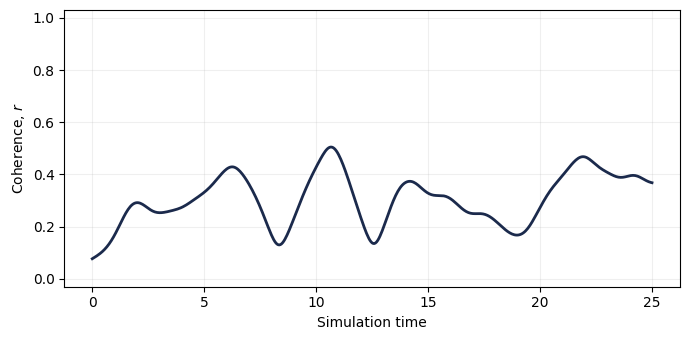

In [19]:
def coherence(phases: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """Return coherence magnitude r and mean phase psi."""
    phases = np.asarray(phases, dtype=float)
    if phases.ndim not in (1, 2):
        raise ValueError("phases must be one- or two-dimensional")
    order = np.mean(np.exp(1j * phases), axis=-1)
    return np.abs(order), np.angle(order)


r_history, psi_history = coherence(phase_history)
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(np.arange(len(r_history)) * baseline.dt, r_history, color=INK, lw=2)
ax.set(xlabel="Simulation time", ylabel="Coherence, $r$", ylim=(-0.03, 1.03))
ax.grid(alpha=0.2)
fig.tight_layout()
plt.show()


# First sweep coupling strength

Use the same seed at every $K$. This paired sweep reveals how one sampled population responds as coupling increases.

> **Up the ladder over coupling:** compare final coherence across a family of simulations.


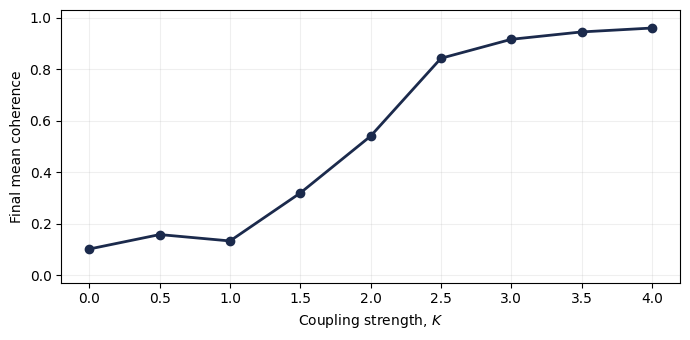

In [20]:
coupling_values = np.linspace(0, 4, 9)
single_run_r = []
for coupling in coupling_values:
    params = KuramotoParameters(coupling=float(coupling))
    history, _ = simulate_kuramoto(params, steps=700, seed=SEED)
    r, _ = coherence(history[-150:])
    single_run_r.append(r.mean())

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(coupling_values, single_run_r, "o-", color=INK, lw=2)
ax.set(xlabel="Coupling strength, $K$", ylabel="Final mean coherence", ylim=(-0.03, 1.03))
ax.grid(alpha=0.2)
fig.tight_layout()
plt.show()


# Then repeat each condition

Each run independently samples initial phases and natural frequencies. The band records run-to-run variation, not uncertainty from measurement error.


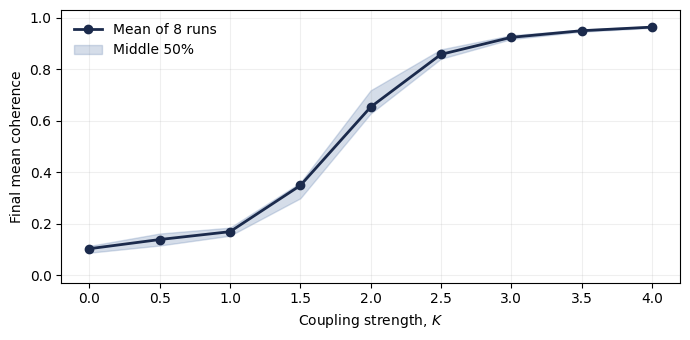

In [21]:
seeds = np.arange(8) + SEED
ensemble = np.empty((len(coupling_values), len(seeds)))
for row, coupling in enumerate(coupling_values):
    params = KuramotoParameters(coupling=float(coupling))
    for column, seed in enumerate(seeds):
        history, _ = simulate_kuramoto(params, steps=700, seed=int(seed))
        r, _ = coherence(history[-150:])
        ensemble[row, column] = r.mean()

mean_r = ensemble.mean(axis=1)
lower, upper = np.quantile(ensemble, [0.25, 0.75], axis=1)

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(coupling_values, mean_r, "o-", color=INK, lw=2, label="Mean of 8 runs")
ax.fill_between(coupling_values, lower, upper, color=BLUE, alpha=0.25, label="Middle 50%")
ax.set(xlabel="Coupling strength, $K$", ylabel="Final mean coherence", ylim=(-0.03, 1.03))
ax.grid(alpha=0.2)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()


## Compare populations, not only coupling values

The standard deviation $\sigma_\omega$ controls the spread of a unimodal frequency distribution. A bimodal population is different in kind, not merely broader: it contains two frequency groups. The experiment below holds the coupling rule, timestep, seeds, and observation window fixed while changing the population distribution and finite population size.

> **Up the ladder over populations:** compare how a distribution-level assumption changes the collective response.


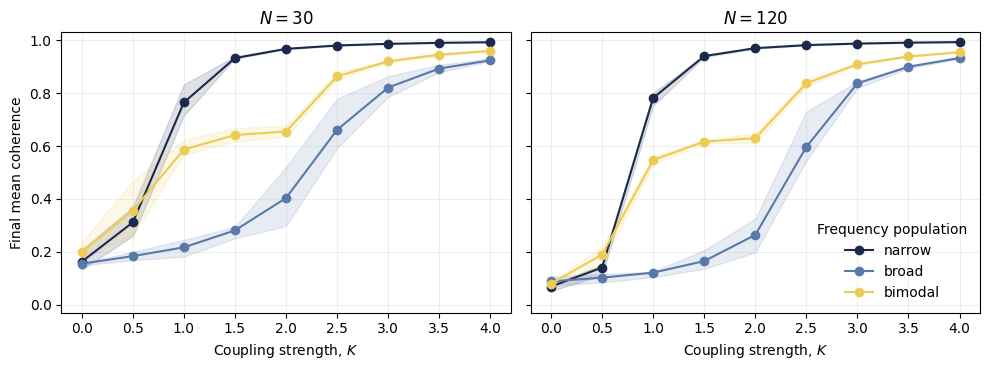

In [22]:
def sample_population(kind: str, n: int, rng: np.random.Generator) -> tuple[np.ndarray, np.ndarray]:
    phases = rng.uniform(-np.pi, np.pi, n)
    if kind == "narrow":
        frequencies = rng.normal(0.0, 0.45, n)
    elif kind == "broad":
        frequencies = rng.normal(0.0, 1.25, n)
    elif kind == "bimodal":
        groups = rng.choice([-1.0, 1.0], size=n)
        frequencies = 1.1 * groups + rng.normal(0.0, 0.22, n)
    else:
        raise ValueError("kind must be narrow, broad, or bimodal")
    frequencies -= frequencies.mean()
    return phases, frequencies


def simulate_population(kind: str, n: int, coupling: float, steps: int, seed: int) -> np.ndarray:
    params = KuramotoParameters(n_oscillators=n, coupling=coupling)
    phases, frequencies = sample_population(kind, n, np.random.default_rng(seed))
    history = np.empty((steps + 1, n))
    history[0] = phases
    for time in range(1, steps + 1):
        order_parameter = np.exp(1j * phases).mean()
        coupling_term = np.imag(order_parameter * np.exp(-1j * phases))
        phases = wrap_phase(phases + params.dt * (frequencies + coupling * coupling_term))
        history[time] = phases
    return history


population_kinds = ("narrow", "broad", "bimodal")
population_sizes = (30, 120)
heterogeneity_seeds = np.arange(6) + SEED
heterogeneity = {}
for kind in population_kinds:
    for n in population_sizes:
        values = np.empty((len(coupling_values), len(heterogeneity_seeds)))
        for row, coupling in enumerate(coupling_values):
            for column, seed in enumerate(heterogeneity_seeds):
                history = simulate_population(kind, n, float(coupling), 700, int(seed))
                r, _ = coherence(history[-150:])
                values[row, column] = r.mean()
        heterogeneity[(kind, n)] = values

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8), sharey=True)
colours = {"narrow": INK, "broad": BLUE, "bimodal": YELLOW}
for ax, n in zip(axes, population_sizes):
    for kind in population_kinds:
        values = heterogeneity[(kind, n)]
        mean = values.mean(axis=1)
        lower, upper = np.quantile(values, [0.25, 0.75], axis=1)
        ax.plot(coupling_values, mean, "o-", color=colours[kind], label=kind)
        ax.fill_between(coupling_values, lower, upper, color=colours[kind], alpha=0.14)
    ax.set(title=f"$N={n}$", xlabel="Coupling strength, $K$", ylim=(-0.03, 1.03))
    ax.grid(alpha=0.2)
axes[0].set_ylabel("Final mean coherence")
axes[1].legend(title="Frequency population", frameon=False)
fig.tight_layout()
plt.show()


The coupling sweep above mixes two effects: changing $K$ and repeatedly sampling finite populations. Now hold the numerical method and network fixed and vary the population itself. Compare narrow, broad, and bimodal natural-frequency distributions at several population sizes.

> **Modelling choice:** A critical-looking coupling is conditional on the frequency distribution, finite $N$, initial phases, network, observation window, and criterion used to call the population synchronised.

Discuss:

1. Over which coupling range does coherence change most strongly?
2. Does broader frequency heterogeneity move or blur that change?
3. Does increasing $N$ reduce run-to-run variation without removing the effect of the distribution?
4. Does high $r$ mean every oscillator is frequency-locked?


# Check heterogeneity before reducing it to one curve

A parameter sweep is useful, but it hides which oscillators lock to the group and which continue to drift. Before changing the model again, inspect the distribution supplied to it and compare natural frequencies with long-time realised frequencies.

> **Down the ladder:** return from the order parameter to the oscillator-level differences that produced it.

> **Up the ladder:** use a histogram, frequency-locking plot, or grouped summary when the individual values are too numerous to read directly.


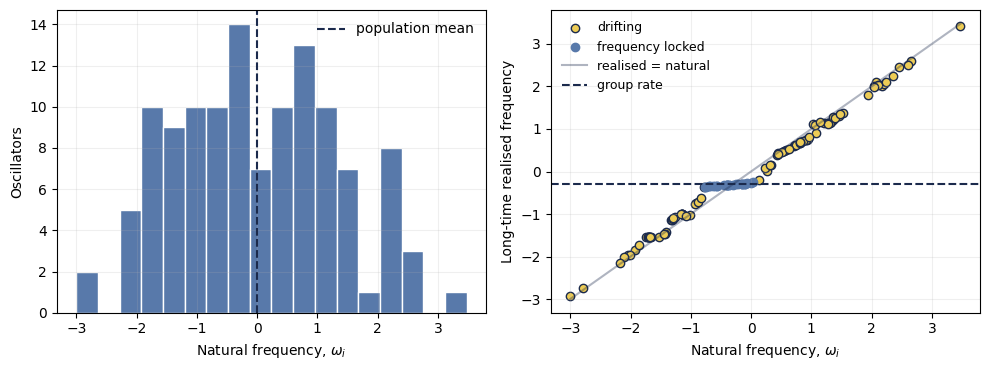

In [23]:
def simulate_given_population(
    phases: np.ndarray, frequencies: np.ndarray, coupling: float, dt: float, steps: int
) -> np.ndarray:
    history = np.empty((steps + 1, len(phases)))
    history[0] = phases
    for time in range(1, steps + 1):
        phases = wrap_phase(
            phases + dt * (frequencies + coupling * kuramoto_coupling(phases))
        )
        history[time] = phases
    return history


rng = np.random.default_rng(SEED)
initial_phases, omega = sample_population("broad", 120, rng)
locked_history = simulate_given_population(initial_phases, omega, coupling=2.4, dt=0.05, steps=1200)
unwrapped_tail = np.unwrap(locked_history[-301:], axis=0)
realised_rate = (unwrapped_tail[-1] - unwrapped_tail[0]) / (300 * 0.05)
group_rate = np.median(realised_rate)
locked = np.abs(realised_rate - group_rate) < 0.08

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
axes[0].hist(omega, bins=18, color=BLUE, edgecolor="white")
axes[0].axvline(omega.mean(), color=INK, ls="--", label="population mean")
axes[0].set(xlabel=r"Natural frequency, $\omega_i$", ylabel="Oscillators")
axes[0].legend(frameon=False)
axes[1].scatter(omega[~locked], realised_rate[~locked], color=YELLOW, edgecolor=INK, label="drifting")
axes[1].scatter(omega[locked], realised_rate[locked], color=BLUE, label="frequency locked")
limits = [min(omega.min(), realised_rate.min()), max(omega.max(), realised_rate.max())]
axes[1].plot(limits, limits, color=INK, alpha=0.35, label="realised = natural")
axes[1].axhline(group_rate, color=INK, ls="--", label="group rate")
axes[1].set(xlabel=r"Natural frequency, $\omega_i$", ylabel="Long-time realised frequency")
axes[1].legend(frameon=False, fontsize=9)
for ax in axes:
    ax.grid(alpha=0.2)
fig.tight_layout()
plt.show()


# Let the interaction network evolve

So far, the interaction network has been fixed and complete. In many systems the state also changes who interacts: agreement can strengthen a connection, disagreement can break one, or spatial motion can create and remove neighbours. This creates an **adaptive network**: oscillator states change the network, and the network changes the oscillator states.

The scaffold below keeps node positions fixed so that rewiring is visible. At each rewiring event it removes an edge joining phases that differ strongly and adds an available edge joining phases that are more similar. The number of edges stays fixed. This is one defensible rule, not a universal model of social or biological rewiring.

> **Modelling decision:** What process should create or remove a connection in the system you want to represent?


In [24]:
def random_adjacency(n: int, mean_degree: int, rng: np.random.Generator) -> np.ndarray:
    probability = mean_degree / (n - 1)
    upper = rng.random((n, n)) < probability
    upper = np.triu(upper, 1)
    return (upper | upper.T).astype(int)


def network_coupling(phases: np.ndarray, adjacency: np.ndarray) -> np.ndarray:
    pairwise = np.sin(phases[None, :] - phases[:, None])
    degree = adjacency.sum(axis=1)
    return (adjacency * pairwise).sum(axis=1) / np.maximum(degree, 1)


def rewire_by_phase_similarity(
    adjacency: np.ndarray, phases: np.ndarray, rng: np.random.Generator
) -> np.ndarray:
    adjacency = adjacency.copy()
    phase_gap = np.abs(np.angle(np.exp(1j * (phases[:, None] - phases[None, :]))))
    existing = np.argwhere(np.triu(adjacency, 1) == 1)
    available = np.argwhere(np.triu(1 - adjacency - np.eye(len(phases), dtype=int), 1) == 1)
    if len(existing) == 0 or len(available) == 0:
        return adjacency
    remove_candidates = existing[phase_gap[existing[:, 0], existing[:, 1]] >= np.quantile(
        phase_gap[existing[:, 0], existing[:, 1]], 0.8
    )]
    add_candidates = available[phase_gap[available[:, 0], available[:, 1]] <= np.quantile(
        phase_gap[available[:, 0], available[:, 1]], 0.2
    )]
    i, j = remove_candidates[rng.integers(len(remove_candidates))]
    u, v = add_candidates[rng.integers(len(add_candidates))]
    adjacency[i, j] = adjacency[j, i] = 0
    adjacency[u, v] = adjacency[v, u] = 1
    return adjacency


def simulate_adaptive_kuramoto(
    n=36, coupling=1.8, frequency_sd=0.65, mean_degree=5,
    dt=0.05, steps=700, rewire_every=5, seed=SEED
):
    rng = np.random.default_rng(seed)
    phases = rng.uniform(-np.pi, np.pi, n)
    frequencies = rng.normal(0, frequency_sd, n)
    frequencies -= frequencies.mean()
    adjacency = random_adjacency(n, mean_degree, rng)
    phase_frames, edge_frames, coherence_history = [], [], []
    for step in range(steps + 1):
        if step % rewire_every == 0:
            phase_frames.append(phases.copy())
            edge_frames.append(np.argwhere(np.triu(adjacency, 1) == 1).tolist())
        coherence_history.append(np.abs(np.mean(np.exp(1j * phases))))
        phases = wrap_phase(phases + dt * (frequencies + coupling * network_coupling(phases, adjacency)))
        if step > 0 and step % rewire_every == 0:
            adjacency = rewire_by_phase_similarity(adjacency, phases, rng)
    return np.array(phase_frames), edge_frames, np.array(coherence_history), frequencies


adaptive_phases, adaptive_edges, adaptive_r, adaptive_omega = simulate_adaptive_kuramoto()
print(f"Stored {len(adaptive_phases)} network frames; mean degree remains approximately {2 * len(adaptive_edges[-1]) / len(adaptive_omega):.1f}.")


Stored 141 network frames; mean degree remains approximately 4.9.


In [25]:
def adaptive_network_player(phase_frames, edge_frames, element_id="adaptive-network-player"):
    phases_json = json.dumps(np.round(phase_frames, 4).tolist())
    edges_json = json.dumps(edge_frames)
    return HTML(f"""
    <div id="{element_id}" style="font-family:Arial,sans-serif;color:#1B2A4C;max-width:760px">
      <p style="margin:0 0 8px 0"><strong>Node colour:</strong> oscillator phase. Colours cycle as phases advance. Node positions are fixed; only the edges rewire.</p>
      <div style="width:min(100%,620px);height:12px;border-radius:6px;background:linear-gradient(90deg,hsl(0,68%,48%),hsl(60,68%,48%),hsl(120,68%,48%),hsl(180,68%,48%),hsl(240,68%,48%),hsl(300,68%,48%),hsl(360,68%,48%));margin-bottom:8px"></div>
      <canvas width="720" height="620" style="width:min(100%,620px);border:1px solid #C7CEDC"></canvas>
      <div style="display:flex;gap:10px;align-items:center;max-width:620px">
        <button type="button">Play</button>
        <input type="range" min="0" max="{len(phase_frames)-1}" value="0" style="flex:1;accent-color:#1B2A4C">
        <span></span>
      </div>
    </div>
    <script>
    (() => {{
      const root=document.getElementById('{element_id}'), phases={phases_json}, edges={edges_json};
      const canvas=root.querySelector('canvas'), ctx=canvas.getContext('2d');
      const slider=root.querySelector('input'), button=root.querySelector('button'), label=root.querySelector('span');
      const n=phases[0].length, cx=canvas.width/2, cy=canvas.height/2, R=245;
      const xy=Array.from({{length:n}},(_,i)=>[cx+R*Math.cos(2*Math.PI*i/n),cy-R*Math.sin(2*Math.PI*i/n)]);
      let timer=null;
      function draw(k) {{
        ctx.clearRect(0,0,canvas.width,canvas.height);ctx.fillStyle='#fff';ctx.fillRect(0,0,canvas.width,canvas.height);
        ctx.strokeStyle='rgba(88,121,170,0.28)';ctx.lineWidth=1.5;
        edges[k].forEach(e=>{{ctx.beginPath();ctx.moveTo(...xy[e[0]]);ctx.lineTo(...xy[e[1]]);ctx.stroke();}});
        phases[k].forEach((a,i)=>{{ctx.fillStyle=`hsl(${{(a+Math.PI)*180/Math.PI}},68%,48%)`;ctx.strokeStyle='#1B2A4C';ctx.lineWidth=1;ctx.beginPath();ctx.arc(xy[i][0],xy[i][1],8,0,2*Math.PI);ctx.fill();ctx.stroke();}});
        label.textContent=`frame ${{k}}`;
      }}
      function stop() {{clearInterval(timer);timer=null;button.textContent='Play';}}
      button.onclick=()=>{{if(timer){{stop();return;}}button.textContent='Pause';timer=setInterval(()=>{{let k=+slider.value;if(k>=phases.length-1){{stop();return;}}slider.value=k+1;draw(k+1);}},90);}};
      slider.oninput=()=>draw(+slider.value);draw(0);
    }})();
    </script>
    """)


display(adaptive_network_player(adaptive_phases, adaptive_edges))


## Analyse more than the animation

An animation helps us inspect the mechanism, but it is not the result. Track coherence alongside a network statistic. The example below uses the fraction of edges joining oscillators whose phases differ by less than $\pi/6$.


In [ ]:
similar_edge_fraction = []
for phases, edges in zip(adaptive_phases, adaptive_edges):
    gaps = [abs(np.angle(np.exp(1j * (phases[i] - phases[j])))) for i, j in edges]
    similar_edge_fraction.append(np.mean(np.asarray(gaps) < np.pi / 6))

frame_time = np.arange(len(adaptive_phases)) * 5 * 0.05
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].plot(np.arange(len(adaptive_r)) * 0.05, adaptive_r, color=INK)
axes[0].set(xlabel="Simulation time", ylabel="Coherence, $r$", ylim=(-0.03, 1.03))
axes[1].plot(frame_time, similar_edge_fraction, color=BLUE)
axes[1].set(xlabel="Simulation time", ylabel="Fraction of phase-similar edges", ylim=(-0.03, 1.03))
for ax in axes:
    ax.grid(alpha=0.2)
fig.tight_layout()
plt.show()


# Further investigation

The workshop has already changed the natural-frequency distribution and allowed the interaction network to rewire. Other sensible directions include:

- changing the shape or width of the natural-frequency distribution;
- assigning different coupling strengths to different oscillators;
- replacing all-to-all coupling with a fixed local, sparse or modular network;
- changing the rewiring rule or its time scale;
- allowing oscillators to move in physical space, as in a swarmalator model.

Choose one direction and turn it into your own investigation. State the question, the one modelling assumption you will change, what you will keep fixed, what you will measure, and what comparison would let you answer the question. Do not change several parts of the model at once.


# Exit ticket

Record:

1. the distinction between phase coincidence and synchronisation;
2. one test that checked the implementation;
3. one conclusion supported by a distribution or ensemble;
4. one modelling assumption encoded by the rewiring rule;
5. the investigation you designed above, including the comparison you would make.
